# Importamos el DataSet de wine 

In [3]:
#1. Importamos el DataSet de wine
from sklearn.datasets import load_wine
import pandas as pd

# Cargar el dataset
wine = load_wine()

# Ver descripción completa
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

# Imports

In [4]:
# Instalamos graphviz
!pip install graphviz

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
from pandas import DataFrame

In [6]:
import warnings
# Ignoramos algunos warnings que se producen por invocar el modelo sin el nombre de las características
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

# Funciones auxiliares

In [7]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [8]:
def remove_labels(df, label_name): #Separa las características de entrada de las de salida
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [9]:
# Muestra información de la evaluación del conjunto transformado y el conjunto original
def evaluate_result(y_pred, y, y_prep_pred, y_prep, metric):
    print(metric.__name__, "WITHOUT preparation:", metric(y_pred, y, average='weighted'))
    print(metric.__name__, "WITH preparation:", metric(y_prep_pred, y_prep, average='weighted'))

# 1. Visualización del conjunto de datos

NOTA: Hemos importado arriba el DataSet, en este ejercicio no tenemos un .csv

In [10]:
# Convertir a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Primeras filas
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [12]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

### Buscando correlaciones

In [13]:
# Copiamos el conjunto de datos y transformamos la variable de salida a numérica para calcular correlaciones
X = df.copy()
X['target'] = X['target'].factorize()[0]

In [14]:
# Calculamos correlaciones
corr_matrix = X.corr()
corr_matrix["target"].sort_values(ascending=False)

target                          1.000000
alcalinity_of_ash               0.517859
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
color_intensity                 0.265668
ash                            -0.049643
magnesium                      -0.209179
alcohol                        -0.328222
proanthocyanins                -0.499130
hue                            -0.617369
proline                        -0.633717
total_phenols                  -0.719163
od280/od315_of_diluted_wines   -0.788230
flavanoids                     -0.847498
Name: target, dtype: float64

In [15]:
X.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


In [16]:
# Se puede llegar a valorar quedarnos con aquellas que tienen mayor correlación
corr_matrix[corr_matrix["target"] > 0.05]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668
target,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717,1.000000


# 2. División del conjunto de datos

In [17]:
# Dividimos el conjunto de datos
train_set, val_set, test_set = train_val_test_split(X)

In [18]:
X_train, y_train = remove_labels(train_set, 'target')
X_val, y_val = remove_labels(val_set, 'target')
X_test, y_test = remove_labels(test_set, 'target')

# 3. Escalando el conjunto de datos

In [19]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [20]:
X_test_scaled = scaler.transform(X_test)

In [21]:
X_val_scaled = scaler.transform(X_val)

In [22]:
# Transformación a un DataFrame de Pandas
X_train_scaled = DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_scaled.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
75,-0.908127,-0.052718,-1.600000,-0.987654,-0.101266,-0.544681,-0.292398,0.000000,-0.600760,-0.343699,0.866142,-0.477231,-0.489400
10,0.816254,0.131796,-0.278261,-0.493827,0.303797,0.595745,0.730994,-0.578313,1.269962,0.294599,0.929134,0.273224,2.132041
147,-0.053004,1.746293,0.347826,0.370370,-0.658228,-0.468085,-0.830409,0.626506,-1.041825,0.916530,-1.307087,-0.681239,-0.012114
123,0.074205,2.530478,-0.869565,0.370370,-0.658228,0.314894,0.339181,-0.192771,0.707224,-0.736498,-0.708661,0.222222,-0.605694
0,0.908127,-0.164745,0.173913,-1.086420,1.417722,0.468085,0.578947,-0.289157,1.133080,0.258592,0.267717,0.819672,1.053907
142,0.406360,0.797364,1.182609,0.864198,-0.101266,-0.595745,-0.906433,0.771084,-1.513308,-0.163666,-0.204724,-0.535519,-0.266505
126,-0.363958,-0.283361,-0.313043,0.370370,-0.658228,0.417021,0.631579,0.240964,0.342205,-0.297872,-0.834646,0.032787,-0.673531
64,-0.547703,-0.336079,0.521739,-0.246914,0.253165,-0.306383,-0.187135,0.530120,-0.783270,-0.621931,1.559055,-0.411658,-0.666263
44,0.074205,-0.125206,-0.973913,-0.740741,0.405063,0.638298,0.543860,-0.289157,0.737643,0.062193,-0.236220,0.404372,0.617807
96,-0.802120,0.105437,1.252174,0.370370,1.772152,-0.553191,-0.631579,-0.963855,0.022814,-0.769231,-0.015748,-0.389800,-0.012114


In [23]:
X_train_scaled.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,1.060000e+02,1.060000e+02,106.000000,106.000000,106.000000
mean,0.005467,0.302384,0.017063,-0.051945,0.060186,0.045765,-0.018813,0.142305,5.509721e-02,6.333570e-02,-0.008736,-0.150737,0.235558
std,0.608313,0.729984,0.931786,0.891269,0.688916,0.568328,0.602077,0.631460,8.554680e-01,7.253520e-01,0.744471,0.536621,0.740136
min,-1.353357,-0.705107,-3.547826,-2.320988,-1.468354,-0.978723,-0.935673,-1.012048,-1.711027e+00,-1.018003e+00,-1.496063,-1.111111,-0.852816
25%,-0.462898,-0.202636,-0.443478,-0.530864,-0.556962,-0.468085,-0.505848,-0.373494,-4.486692e-01,-5.335516e-01,-0.551181,-0.710383,-0.327075
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.682682e-16,1.457168e-16,0.000000,0.000000,0.000000
75%,0.537102,0.797364,0.556522,0.469136,0.443038,0.531915,0.494152,0.626506,5.513308e-01,4.664484e-01,0.448819,0.289617,0.672925
max,1.332155,2.530478,2.956522,2.469136,2.025316,1.387234,1.760234,1.542169,3.095057e+00,1.947627e+00,2.377953,0.819672,2.221684


# 4. Arbol de decisión

In [24]:
from sklearn.tree import DecisionTreeClassifier

MAX_DEPTH = 20

# Modelo entrenado con el conjunto de datos sin escalar
clf_tree = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
clf_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
# Modelo entrenado con el conjunto de datos escalado
clf_tree_scaled = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
clf_tree_scaled.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
# Predecimos con el conjunto de datos de entrenamiento
y_train_pred = clf_tree.predict(X_train)
y_train_prep_pred = clf_tree_scaled.predict(X_train_scaled)

In [27]:
# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_train_pred, y_train, y_train_prep_pred, y_train, f1_score)

f1_score WITHOUT preparation: 1.0
f1_score WITH preparation: 1.0


In [28]:
# Predecimos con el conjunto de datos de validación
y_pred = clf_tree.predict(X_val)
y_prep_pred = clf_tree_scaled.predict(X_val_scaled)

In [29]:
# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_pred, y_val, y_prep_pred, y_val, f1_score)

f1_score WITHOUT preparation: 0.9722705314009663
f1_score WITH preparation: 0.9722705314009663


# 5. Visualizando el límite de decisión

In [30]:
# Reducimos el número de atributos del conjunto de datos para visualizarlo mejor
X_train_reduced = X_train[['alcohol', 'malic_acid']]

In [31]:
# Generamos un modelo con el conjunto de datos reducido
clf_tree_reduced = DecisionTreeClassifier(max_depth=20, random_state=42)
clf_tree_reduced.fit(X_train_reduced, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


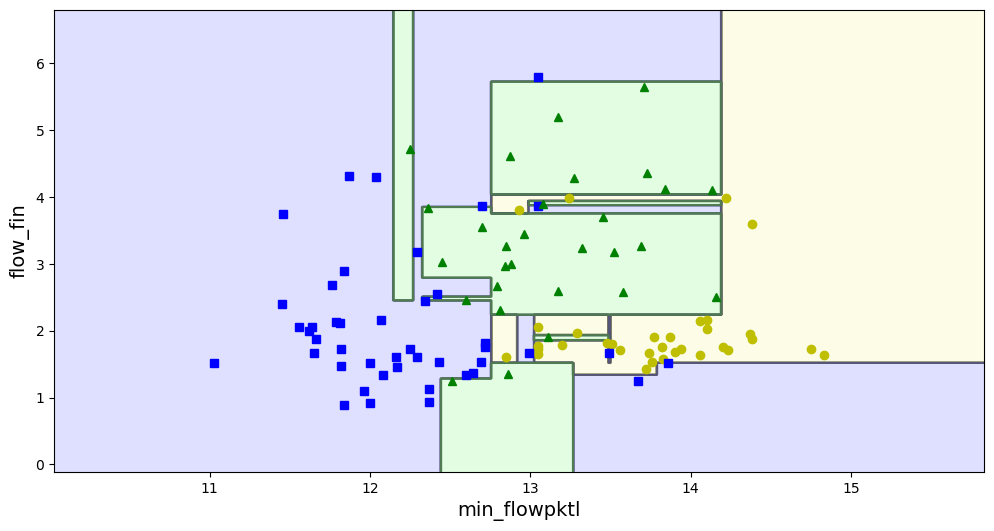

In [32]:
# Representamos gráficamente el límite de decisión construido
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
%matplotlib inline

def plot_decision_boundary(clf, X, y, plot_training=True, resolution=1000):
    mins = X.min(axis=0) - 1
    maxs = X.max(axis=0) + 1
    x1, x2 = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
    plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="normal")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="adware")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="malware")
        plt.axis([mins[0], maxs[0], mins[1], maxs[1]])               
    plt.xlabel('min_flowpktl', fontsize=14)
    plt.ylabel('flow_fin', fontsize=14, rotation=90)

plt.figure(figsize=(12, 6))
plot_decision_boundary(clf_tree_reduced, X_train_reduced.values, y_train)
plt.show()

# Cada clase está pintada de un color, amarillo las normales, azul adware y verde malware... pinta con líneas en verde los límites de decisión que establece

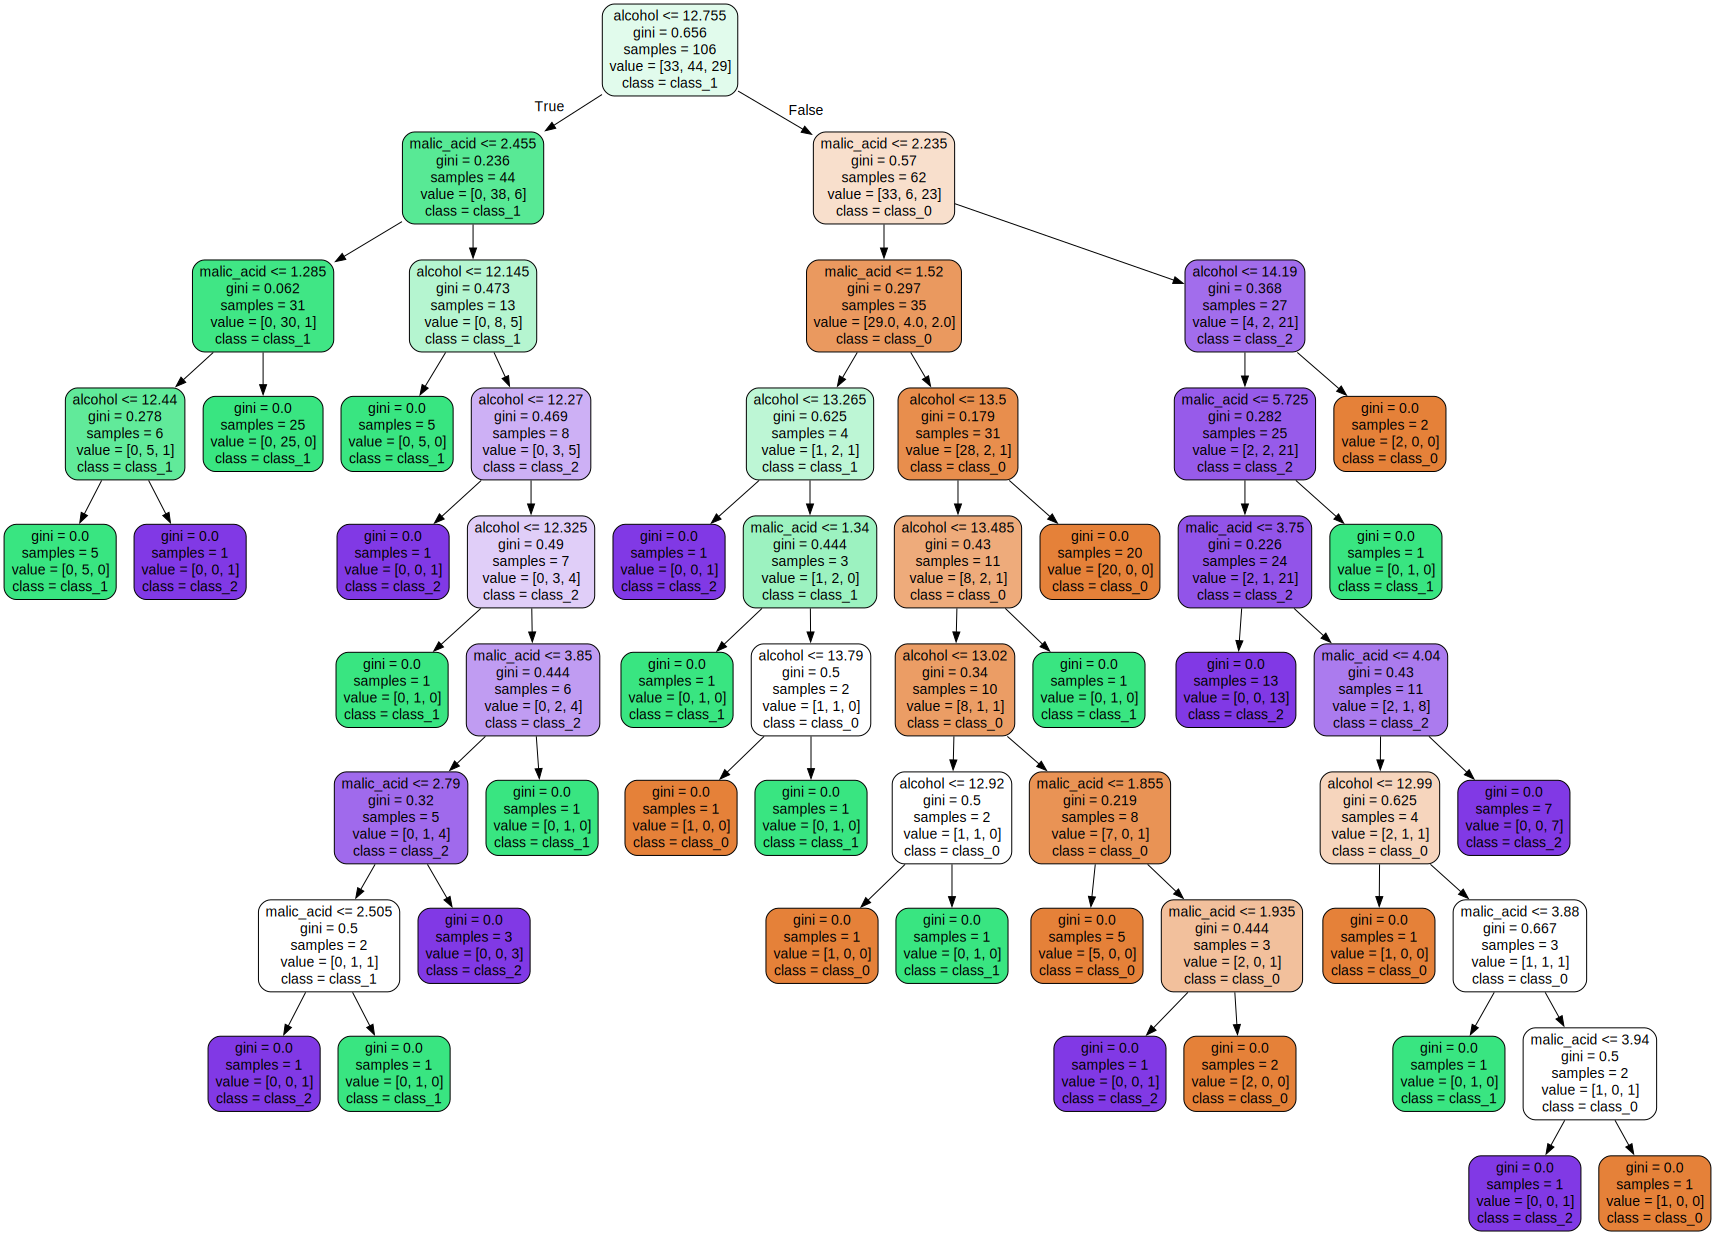

In [33]:
# Pintamos el árbol para compararlo con la representación gráfica anterior
from graphviz import Source
from sklearn.tree import export_graphviz
import os

export_graphviz(
        clf_tree_reduced,
        out_file="wine_output.dot",
        feature_names=X_train_reduced.columns,
        class_names=["class_0", "class_1", "class_2"],
        rounded=True,
        filled=True
    )
Source.from_file("wine_output.dot")

# 6. Decision Forest (se vuelve a calcular sin limitador)

In [34]:
# Modelo entrenado con el conjunto de datos sin escalar
from sklearn.tree import DecisionTreeClassifier

clf_tree = DecisionTreeClassifier(random_state=42) #No limito las ramas
clf_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
# Predecimos con el conjunto de datos de entrenamiento
y_train_pred = clf_tree.predict(X_train)

print("F1 Score Train Set:", f1_score(y_train_pred, y_train, average='weighted'))

F1 Score Train Set: 1.0


In [36]:
# Predecimos con el conjunto de datos de validación
y_val_pred = clf_tree.predict(X_val)

print("F1 Score Validation Set:", f1_score(y_val_pred, y_val, average='weighted'))

F1 Score Validation Set: 0.9722705314009663


NOTA: Si comparamos estos dos últimos valores de F1 Score podemos darnos cuenta de que hay un pequeño sobreajuste (overlifting) ya que el conjunto de entrenamiendo predice perfecto (1) pero el conjunto de validación no es del todo correcto (0.97)

# 7. Random Forests

In [37]:
from sklearn.ensemble import RandomForestClassifier

# Modelo entrenado con el conjunto de datos sin escalar
clf_rnd = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) #número de 100 árboles de decisión aleatorios
clf_rnd.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
# Modelo entrenado con el conjunto de datos escalado
clf_rnd_scaled = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rnd_scaled.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
# Predecimos con el conjunto de datos de entrenamiento
y_train_pred = clf_rnd.predict(X_train)
y_train_prep_pred = clf_rnd_scaled.predict(X_train_scaled)

# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_train_pred, y_train, y_train_prep_pred, y_train, f1_score)

f1_score WITHOUT preparation: 1.0
f1_score WITH preparation: 1.0


In [46]:
# Predecimos con el conjunto de datos de validación
y_pred = clf_rnd.predict(X_val)
y_prep_pred = clf_rnd_scaled.predict(X_val_scaled)

# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_pred, y_val, y_prep_pred, y_val, f1_score)

f1_score WITHOUT preparation: 1.0
f1_score WITH preparation: 1.0


In [47]:
# Predecimos con el conjunto de datos de prueba (test)
y_test_pred = clf_rnd.predict(X_test)
y_test_scaled_pred = clf_rnd_scaled.predict(X_test_scaled)

# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_test_pred, y_test, y_test_scaled_pred, y_test, f1_score)

f1_score WITHOUT preparation: 1.0
f1_score WITH preparation: 1.0


NOTA: Con random forest volvemos a reentrenar el modelo sin limitaciones, en este caso el f1_score de los datos de entrenamiento, validación y test da 1 por lo tanto esto nos puede llevar a pensar que el modelo es perfecto pero no es así, estos valores nos dicen que puede haber un sobreajuste (overlifting) debido a que no se han limitado las ramas de entrenamiento

# 8. Extraemos características con random forest

In [48]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [49]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

### Importancia de las características

In [53]:
clf_rnd.feature_importances_

array([0.13879326, 0.03458518, 0.01407283, 0.05418392, 0.02980512,
       0.03746925, 0.19335564, 0.00992324, 0.02996741, 0.17220346,
       0.06453027, 0.09878634, 0.12232409])

In [56]:
# Podemos extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(df), clf_rnd.feature_importances_)}

feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(20)

flavanoids                      0.193356
color_intensity                 0.172203
alcohol                         0.138793
proline                         0.122324
od280/od315_of_diluted_wines    0.098786
hue                             0.064530
alcalinity_of_ash               0.054184
total_phenols                   0.037469
malic_acid                      0.034585
proanthocyanins                 0.029967
magnesium                       0.029805
ash                             0.014073
nonflavanoid_phenols            0.009923
dtype: float64

### Reducción del número de características

In [58]:
# Extraemos las 10 caracteristicas con mas relevancia para el algoritmo
columns = list(feature_importances_sorted.head(10).index)

columns

['flavanoids',
 'color_intensity',
 'alcohol',
 'proline',
 'od280/od315_of_diluted_wines',
 'hue',
 'alcalinity_of_ash',
 'total_phenols',
 'malic_acid',
 'proanthocyanins']

In [59]:
X_train_reduced = X_train[columns].copy()
X_val_reduced = X_val[columns].copy()

X_train_reduced.head(10)

,flavanoids,color_intensity,alcohol,proline,od280/od315_of_diluted_wines,hue,alcalinity_of_ash,total_phenols,malic_acid,proanthocyanins
75,1.57,3.80,11.66,428.0,2.14,1.23,16.0,1.61,1.88,1.15
10,3.32,5.75,14.10,1510.0,3.17,1.25,18.0,2.95,2.16,2.38
147,0.65,7.65,12.87,625.0,1.86,0.54,21.5,1.70,4.61,0.86
123,2.65,2.60,13.05,380.0,3.10,0.73,21.5,2.62,5.80,2.01
0,3.06,5.64,14.23,1065.0,3.92,1.04,15.6,2.80,1.71,2.29
142,0.52,4.35,13.52,520.0,2.06,0.89,23.5,1.55,3.17,0.55
126,3.15,3.94,12.43,352.0,2.84,0.69,21.5,2.74,1.53,1.77
64,1.75,2.95,12.17,355.0,2.23,1.45,19.0,1.89,1.45,1.03
44,3.00,5.04,13.05,885.0,3.35,0.88,17.0,3.00,1.77,2.03
96,0.99,2.50,11.81,625.0,2.26,0.95,21.5,1.60,2.12,1.56


In [60]:
from sklearn.ensemble import RandomForestClassifier

clf_rnd = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf_rnd.fit(X_train_reduced, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
# Predecimos con el conjunto de datos de validación
y_pred = clf_rnd.predict(X_val_reduced)

In [62]:
print("F1 score:", f1_score(y_pred, y_val, average='weighted'))

F1 score: 1.0


NOTA: Vuelve a salir un F1 score de 1, esto puede ser debido a que el dataset tiene 178 filas y por lo tanto para el modelo es muy facil realizar predicciones sobre este modelo

# 9. Extraemos características con PCA

In [65]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [66]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [68]:
# Separamos las variables de entrada (X) de la etiqueta (y)
# Transformamos y a valor numérico
X_df, y_df = remove_labels(df, 'target')
y_df = y_df.factorize()[0]

In [69]:
# Reducimos el conjunto de datos a 2 dimensiones utilizando el algoritmo PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_reduced = pca.fit_transform(X_df)

In [71]:
df_reduced = pd.DataFrame(df_reduced, columns=["c1", "c2"])

df_reduced.head(10)

,c1,c2
0,318.562979,21.492131
1,303.097420,-5.364718
2,438.061133,-6.537309
3,733.240139,0.192729
4,-11.571428,18.489995
5,703.231192,-0.332159
6,542.971581,-13.518967
7,548.401860,11.449432
8,298.036863,-8.180158
9,298.049553,-7.101543


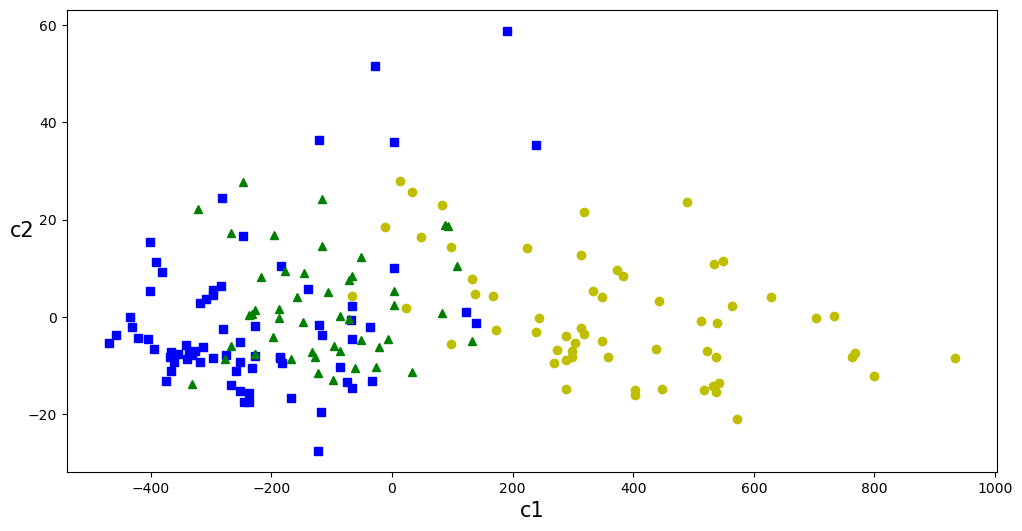

In [72]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(12, 6))
plt.plot(df_reduced["c1"][y_df==0], df_reduced["c2"][y_df==0], "yo", label="normal")
plt.plot(df_reduced["c1"][y_df==1], df_reduced["c2"][y_df==1], "bs", label="adware")
plt.plot(df_reduced["c1"][y_df==2], df_reduced["c2"][y_df==2], "g^", label="malware")
plt.xlabel("c1", fontsize=15)
plt.ylabel("c2", fontsize=15, rotation=0)
plt.show()

In [73]:
# Calculamos la proporción de varianza que se ha preservado del conjunto original
pca.explained_variance_ratio_

array([0.99809123, 0.00173592])

In [74]:
# Generamos un modelo con el conjunto de datos reducido
from sklearn.tree import DecisionTreeClassifier

clf_tree_reduced = DecisionTreeClassifier(max_depth=15, random_state=42)
clf_tree_reduced.fit(df_reduced, y_df)

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


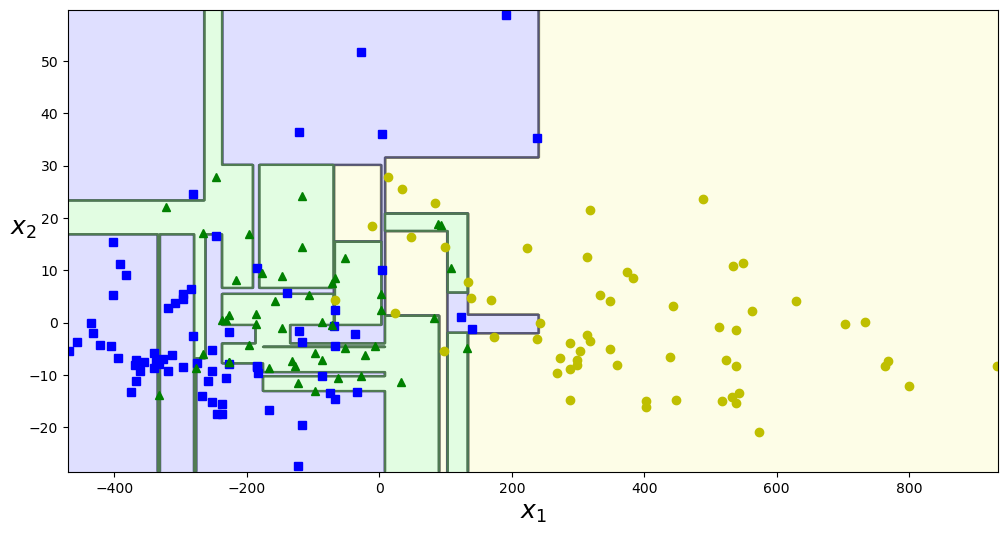

In [75]:
# Representamos el límite de decisión generado por el modelo
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, plot_training=True, resolution=1000):
    mins = X.min(axis=0) - 1
    maxs = X.max(axis=0) + 1
    x1, x2 = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
    plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="normal")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="adware")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="malware")
        plt.axis([mins[0], maxs[0], mins[1], maxs[1]])               
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

plt.figure(figsize=(12, 6))
plot_decision_boundary(clf_tree_reduced, df_reduced.values, y_df)
plt.show()

In [76]:
# Reducimos el conjunto de datos manteniendo el 99,9% de varianza
from sklearn.decomposition import PCA

pca = PCA(n_components=0.999) # Si le pongo un valor comprendido entre 0 y 1 interpreta cuánto porcentaje tiene que mantener de la varianza
df_reduced = pca.fit_transform(X_df)

In [77]:
# Numero de dimensionaes del nuevo conjunto
print("Número de componentes:", pca.n_components_)

Número de componentes: 2


In [78]:
# Calculamos la proporción de varianza que se ha preservado del conjunto original
pca.explained_variance_ratio_

array([0.99809123, 0.00173592])

In [80]:
# Transformamos a un DataFrame de Pandas
df_reduced = pd.DataFrame(df_reduced, columns=["c1", "c2"])
df_reduced["Class"] = y_df
df_reduced

,c1,c2,Class
0,318.562979,21.492131,0
1,303.097420,-5.364718,0
2,438.061133,-6.537309,0
3,733.240139,0.192729,0
4,-11.571428,18.489995,0
...,...,...,...
173,-6.980211,-4.541137,2
174,3.131605,2.335191,2
175,88.458074,18.776285,2
176,93.456242,18.670819,2


In [82]:
# Dividimos el conjunto de datos
train_set, val_set, test_set = train_val_test_split(df_reduced)

X_train, y_train = remove_labels(train_set, 'Class')
X_val, y_val = remove_labels(val_set, 'Class')
X_test, y_test = remove_labels(test_set, 'Class')

In [83]:
from sklearn.ensemble import RandomForestClassifier

clf_rnd = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1)
clf_rnd.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
# Predecimos con el conjunto de datos de validación
y_val_pred = clf_rnd.predict(X_val)

# F1 score conjunto de datos de validación
print("F1 score validation test:", f1_score(y_val_pred, y_val, average='weighted'))

F1 score validation test: 0.6711344211344211


In [87]:
# Predecimos con el conjunto de datos de pruebas
y_test_pred = clf_rnd.predict(X_test)

In [88]:
# F1 score conjunto de datos de pruebas
print("F1 score test set:", f1_score(y_test_pred, y_test, average='weighted'))

F1 score test set: 0.7468710089399744


NOTA: Ahora al elegir las características más importantes del dataset (en nuestro caso el modelo ha decidido coger 2 componentes) hemos eliminado el sobreajuste (overlifting) 